# Lab 059 · When validation becomes training

[Lesson](../lessons/0059-validation-set-overfitting.html) · [Reference](../reference/0059-validation-set-overfitting.html) · [Reproduction contract](l059-reproduction.md)

**Route:** retrieve → explain → predict → implement → CHECK → inspect evidence → EXIT. PROVIDED cells are readable implementation and peripheral support. TODOs contain your load-bearing code; CHECKs give immediate diagnostic feedback. Complete the code before revealing teacher solutions. Core study: 35–50 minutes; lab: 45–75 minutes plus explicitly gated larger runs.

**Before reading:** Must searching more noise candidates improve independent test performance? Write your answer and justify the information boundary. Then recall one older lesson that could expose an error in this experiment.

**Evidence contract:** numerical figures labeled author-reference come from committed author measurements. They are not outputs of your current kernel. Reduced model mechanisms, pretrained reference inference, frozen-result reanalysis and paper reproduction are different tracks. Every track states its scope below.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## The validation set becomes training data for your decisions

Your goal is to diagnose a procedure that improves its validation score while learning nothing useful. A model's training loss measures how its parameters fit training examples. Its validation loss guides decisions such as hyperparameters, stopping epochs, preprocessing, retrieved context sizes and ensemble weights. Once a decision depends on validation labels, those labels have trained the **selection procedure**, even if no gradient used them.

This extends lesson 57: an out-of-fold prediction excludes a row from fitting its base predictor, but the row's label still fits the combiner. Read [Cawley and Talbot, Section 2](https://jmlr.org/papers/v11/cawley10a.html) for the distinction between overfitting the selection criterion and overfitting model parameters. Read [TabArena's protocol](https://arxiv.org/html/2506.16791v1) with that distinction in mind. A benchmark can constrain individual trials while users adapt repeatedly to its reported results.

### A human decision can fit noise without a gradient

Training data changes model parameters directly. Validation data changes which parameters, recipes and ideas survive. If you repeatedly inspect validation outcomes and adapt your next attempt, the overall development procedure is learning from that validation set even when no optimizer receives its labels.

This includes choosing hyperparameters, early stopping, selecting features, deciding whether to keep an augmentation, picking ensemble members and revising preprocessing after inspecting failures. Counting only launched model configurations undercounts the adaptive decisions that used the same feedback.

The problem is not that validation should never guide development. That is its purpose. The problem is treating the performance of the selected candidate on the selection data as an unbiased estimate of how the selected procedure will behave on new data.

Let the observed validation loss of candidate j be its true expected loss μⱼ plus estimation noise εⱼ. Selection chooses the smallest μⱼ+εⱼ. When several candidates have similar μ, the winner is disproportionately likely to have a favorable negative ε. Its observed validation loss then overstates how good its true loss is.

If candidates are strongly correlated, the effective number of distinct opportunities for lucky noise can be smaller than the raw count. If they are diverse or the validation sample is small, selection can be more aggressive. There is no universal correction based only on the number of model names.

### More detailed feedback creates more ways to adapt

A single aggregate validation score supplies one kind of feedback. Per-row errors, subgroup plots, feature attributions and repeated threshold curves supply much richer information. That richness is useful for diagnosis, but it also gives development more opportunities to specialize to the observed validation sample.

Imagine inspecting 50 subgroups and changing the model to fix the worst one. Some subgroup may be worst partly by sampling noise, especially when it contains few rows. If you then report improvement on the same subgroup and same rows, the result combines real adaptation with selection of an extreme. A new subgroup sample or a prespecified independent evaluation is needed to assess the repair.

Repeated cross-validation does not eliminate this issue if the same fold results repeatedly guide idea selection. It can reduce variance of individual estimates while still supplying adaptive feedback. More precise feedback and independent final evaluation are complementary, not interchangeable.

The practical response is to distinguish exploration from confirmation. Use development evidence actively, record the changes it motivated, and reserve independent evidence for the claims you finally want to defend. The adaptation ledger is useful because it captures choices made by the researcher as well as choices made by code.

## A minimum selects lucky noise

Write each candidate's observed validation error as true error plus estimation noise: `E_hat_j = E_j + epsilon_j`. Selection chooses the smallest observed value. Even when each noise term is centered at zero, the noise of the selected candidate tends to be negative. Independence is not required for this effect, although strong correlation between candidates can reduce the effective search size.

For three equally good candidates with true error `.30`, suppose noise is `+.03, −.04, +.01`. Validation reports `.33, .26, .31`, so the second candidate wins. Its expected new-data error remains `.30` under the equal-quality assumption. The apparent gain is a lucky selection event. Repeating candidate construction after inspecting validation makes the family of decisions still larger.

### A two-candidate example already creates optimism

Suppose two candidates have the same true loss 0.5. Each validation estimate independently equals 0.4 or 0.6 with equal probability. The four equally likely pairs are (0.4,0.4), (0.4,0.6), (0.6,0.4) and (0.6,0.6). The selected minimum is 0.4 in three cases and 0.6 in one, so its expected value is 0.45.

Nothing predictive was learned, yet the selected validation estimate is 0.05 better than the true loss. A fresh independent test estimate still has expectation 0.5 for the selected candidate. Selection created the gap by conditioning on favorable validation noise.

With more candidates, the minimum can become more extreme. Increasing validation sample size reduces the variability of each estimate and generally reduces this mechanism, but it does not make arbitrary repeated adaptation free. Correlation among candidates and unequal true performance complicate the exact amount.

For pure random binary predictions on balanced random labels, each validation error is a binomial proportion. With n independent examples and error probability 0.5, its standard deviation is 0.5/√n. At n=100 this is 0.05; at n=400 it is 0.025. Searching many such estimates can reveal apparently impressive candidates that still carry no signal.

This calculation is a negative-control model, not a forecast of the exact optimism in a real benchmark. Real candidates have different true risks and correlated errors. The control isolates the selection mechanism precisely because those complications are removed.

<div style="overflow-x:auto;max-width:100%">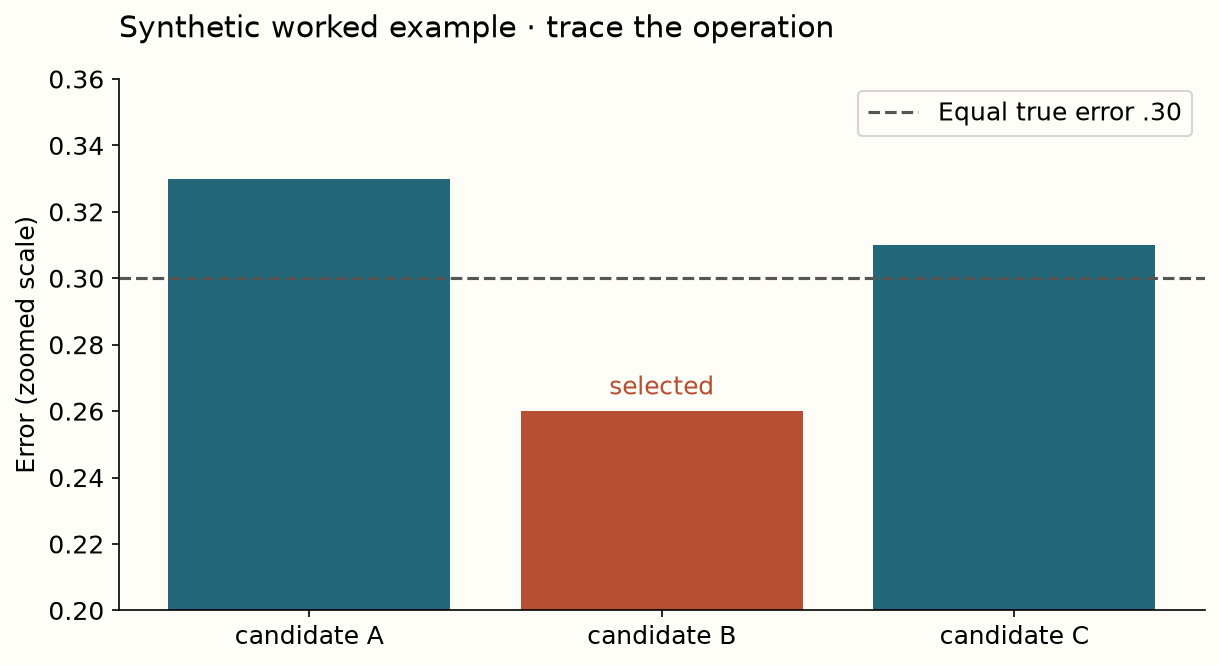</div>

*L059 mechanism: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

## Run a negative control you can explain completely

The lab generates balanced random labels and independent random candidate predictions. Each candidate's expected classification error is one half. It selects among 1, 4, 16, 64 or 256 candidates using 80 validation examples, then evaluates that frozen choice on 2,000 separately generated test examples. The validation and test streams use separate random-number generators, so changing the number of candidates cannot accidentally reuse validation draws as test data.

Across 200 repetitions, report mean validation error, test error and **optimism**, defined here as `test_error − validation_error`. Positive optimism means the selected validation score looked too favorable. The standard error across these independent synthetic repetitions quantifies Monte Carlo precision; it is not a confidence interval for a real tabular benchmark. Candidate prefixes are nested within a repetition, which makes budget comparisons paired.

Predict the two curves before revealing them. Increasing search should improve the selected validation minimum; it should not systematically improve independent test performance when every candidate is noise. A single repetition can fluctuate in either direction. That exception is useful: the statistical statement concerns the selection distribution, not monotonic test error in every run.

### Independence must survive the implementation

Generate candidate validation predictions without signal, select the best validation candidate and only then generate or reveal its independent test predictions. The test random stream must not be chosen or filtered based on validation success. Reusing labels, predictions or random state incorrectly can create dependence that defeats the purpose of the control.

The local experiment uses separate random streams for validation and test. This makes the causal story clear: the candidate index depends on validation noise, while test outcomes remain independent of that index's favorable validation realization. A reproducible seed identifies the simulation; it is not evidence of statistical independence unless the generation logic enforces it.

Run many independent repetitions of the entire search. For each repetition record selected validation error, selected test error and their difference. The mean difference estimates optimism under this simulation. Its Monte Carlo standard error describes numerical uncertainty from a finite number of simulation repetitions.

Do not confuse that Monte Carlo standard error with variation between real datasets or with a model's test-set sampling uncertainty. These are different random objects. A very precise simulation estimate can teach a general mechanism while saying little about the exact size of the effect in your application.

Inspect the distribution as well as the mean. Some repetitions can produce unusually good or bad test outcomes by chance. The expected test performance remains at chance; each finite realization need not equal exactly 0.5. A test error of 0.47 in one run is not a contradiction of the negative-control argument.

<div style="overflow-x:auto;max-width:100%">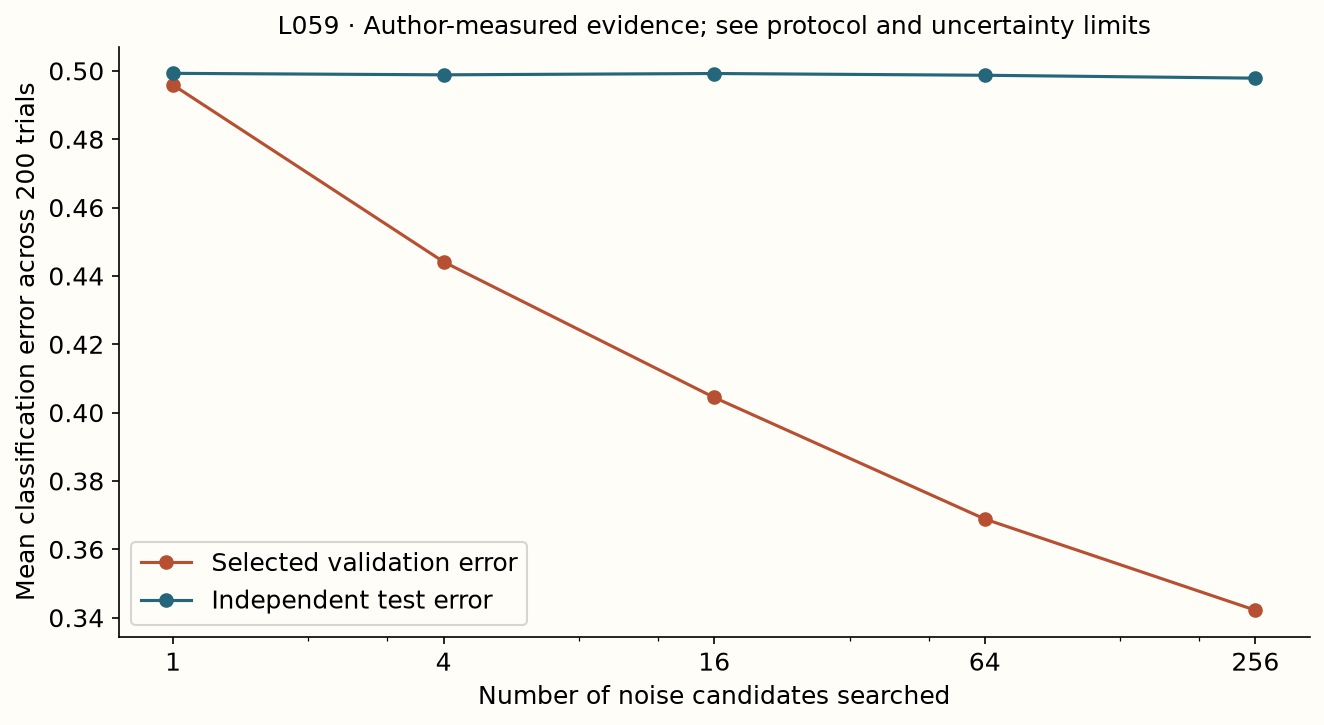</div>

*L059 results: author-reference measurements, separate from your kernel. Scroll wide figures horizontally on small screens.*

## Nest the decision that is actually adaptive

An outer split evaluates an entire procedure. Within its training portion, create inner fitting and validation data; perform all recipe and ensemble decisions there; refit only according to a declared rule; then score once on the outer test. Repeat outer splits when your evaluation target allows it. For temporal deployment, preserve chronology rather than randomly nesting future rows into earlier fitting sets.

The common mistake is to nest only the last numerical optimizer. If you chose features, model families or an ensemble library after reading outer scores, that redesign also belongs inside the evaluated procedure—or requires new evaluation evidence. A second test set is not permanently untouched once you repeatedly use it to guide decisions. [Cawley and Talbot](https://jmlr.org/papers/v11/cawley10a.html).

OOF predictions alone are not a certificate against meta-level leakage. Suppose you train a head on OOF embeddings from several folds: check whether any “held-out” meta-evaluation target influenced the base models that generated the head's fitting features. Distinguish an audit of frozen predictions from a fresh nested evaluation. Record who fitted each layer and which labels they could access.

### Evaluate the whole selection procedure in the outer loop

In nested evaluation, the outer training partition contains an inner training/validation process. All candidate choices happen inside that outer training data. The selected procedure is then fitted according to the declared policy and evaluated on the untouched outer test partition. Repeating outer splits evaluates the procedure that includes selection.

The object being estimated is therefore not the score of one configuration chosen using the full dataset. It is the performance of an algorithm that receives a training sample and carries out its selection process. This distinction explains why a nested estimate and the final fitted model are related but not identical objects.

Every adaptive preprocessing decision must be nested too. Selecting features once using all labels before the outer loop leaks information even if the inner hyperparameter search is carefully implemented. The same applies to choosing ensemble membership or a representation layer from outer-test feedback.

Nested evaluation costs more because it repeats selection. A practical alternative can be a strictly held-out final test used once after development, provided the development process and data size make that reasonable. The appropriate design depends on the decision and available data; the invariant is that final evaluation must be independent of the choices it assesses.

### Ensembles add another selection layer

Uniformly averaging a fixed declared set of members is different from searching thousands of subsets on one validation set. The latter can overfit the combiner selection even when the members are diverse and individually well trained. Diversity and validation optimism are separate mechanisms.

Keep an adaptation ledger: which feedback was viewed, what decision it changed and which independent evidence remains. If test results motivate a new hypothesis, record the hypothesis and evaluate it on fresh evidence. The exit task is to make the adaptive procedure visible enough that another researcher can reproduce both its choices and its final evaluation.

## Audit an ensemble without blaming diversity

For the lesson-57 combiner, count the base-family recipes, fold schemes, preprocessing variants, weight searches, maximum step counts and prefix-selection rules that were tried. Compare a prespecified uniform mixture, a prespecified greedy procedure and a single family selected by the same inner evidence. Do not call the family with minimum test loss a deployable best-single comparator; that identity is an oracle available only after evaluation.

A growing OOF-to-test gap can arise from selection overfitting, distribution shift, different fold versus refit behavior, or ordinary uncertainty. The pure-noise experiment isolates one mechanism, not every explanation for a disappointing ensemble. A useful diagnosis proposes a discriminating experiment: freeze the whole procedure and evaluate a new outer split, or hold predictions fixed while varying only the amount of selection data.

## Exit: make adaptation countable

Implement the selector without a test-label argument, run the negative control and report paired budget differences. Then write a decision ledger for lesson 60 with the metric, candidate lists, stopping rule, split identities and a freeze point. Name one tempting adjustment you will postpone until a separately labeled follow-up experiment. Explain why a better validation number can coexist with no improvement in the underlying predictor.

## Reproduction contract and task support

The visible code below implements the named operator or reduced architecture. The full pretrained model is a separately pinned reference path. Real public-table experiments use Tier A data; synthetic coin/SCM/shift tasks are Tier C mechanism isolation. Seeds, row identities, recipe budgets, versions and source/checkpoint hashes are available in the linked contract and evidence. Numerical agreement with a local operator is not a paper-table reproduction.

In [ ]:
# PROVIDED — environment, peripheral data/metric utilities
import os, sys, math, copy, re, json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.stats import rankdata, friedmanchisquare, studentized_range, t
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold
from threadpoolctl import threadpool_limits
from IPython.display import display
for directory in [Path.cwd(), Path.cwd()/'labs', Path.cwd().parent]:
    if (directory/'relkit').is_dir():
        ROOT=directory.resolve(); sys.path.insert(0,str(ROOT)); break
else:
    raise RuntimeError('Run the Colab bootstrap or start in the course repository')
torch.set_num_threads(1)
from relkit.foundation_benchmark import random_task, encode_train
print('CPU mechanism track; official checkpoint reruns use an isolated subprocess after EXIT.')

In [ ]:
# PROVIDED — validation_audit; inspect the live function calls
def validation_audit():
    rows=[]
    for seed in range(200):
        for budget in [1,4,16,64,256]:
            row=null_search(budget,80,2000,59+seed);row['seed']=seed;rows.append(row)
    frame=pd.DataFrame(rows);summary=[]
    for budget,g in frame.groupby('candidates'):
        gap=g.test_error-g.validation_error
        summary.append(dict(candidates=int(budget),validation_error=float(g.validation_error.mean()),test_error=float(g.test_error.mean()),
            optimism=float(gap.mean()),monte_carlo_se=float(gap.std(ddof=1)/np.sqrt(len(gap)))))
    return dict(scope='Synthetic pure-noise negative control, 200 independent trials',rows=rows,summary=summary,
        validation_rows=80,test_rows=2000,verdict='MECHANISM_ONLY',paper_reproduction='NOT_RUN')

## TODO 1 · choose_validation

**Goal:** Choose the first finite minimum validation error; reject empty/nonfinite vectors.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 1 — choose_validation
def choose_validation(errors):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 1 — choose_validation
assert choose_validation([.4,.2,.3])==1
assert choose_validation([.2,.2,.3])==0, 'Declare deterministic tie handling'
for bad in ([],[.2,np.nan],[np.inf]):
    try: choose_validation(bad)
    except ValueError: pass
    else: raise AssertionError('Invalid validation vector accepted')

print("PASS: choose_validation")

## TODO 2 · null_search

**Goal:** Build the pure-noise negative control with separate validation/test RNG streams. Generate test predictions only after the validation choice.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 2 — null_search
def null_search(candidates, n_validation, n_test, seed=59):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 2 — null_search
small=null_search(1,80,2000,59);large=null_search(256,80,2000,59)
assert large['validation_error']<=small['validation_error'], 'Nested candidate set cannot worsen the selected validation minimum'
assert abs(large['test_error']-.5)<.06, 'Noise-only test performance should remain near chance on this deterministic fixture'
assert large['selected']<256

print("PASS: null_search")

## Run your live implementation

Predict the outcome before execution. This cell calls the functions you just wrote. Changing a TODO must change the corresponding computation or make a CHECK fail. The text printed with the result identifies whether this is a small training run, a mechanism test or a reanalysis of committed measurements.

In [ ]:
# PROVIDED — experiment driven by your live functions
trial=validation_audit()
display(pd.DataFrame(trial['summary']))
assert trial['summary'][-1]['optimism']>trial['summary'][0]['optimism']

## Audit author-reference evidence

Inspect the measured results below independently of your smoke experiment. A fresh smoke may use a smaller budget. Preserve the protocol difference rather than forcing numerical agreement with a different run. The committed prediction arrays let you reconstruct scores without downloading pretrained weights.

In [ ]:
# PROVIDED — readable evidence, never impersonating current-kernel training
author=json.loads((ROOT/'_verify_l059_results.json').read_text())
print('AUTHOR REFERENCE:',author.get('scope',author.get('note','Declared checkpoint experiment')))
print('Evidence verdict:',author.get('verdict'))
rows=author.get('records',author.get('summary',[]))
if isinstance(rows,list) and rows:
    display(pd.DataFrame(rows).drop(columns=['predictions','targets','history','context_ids','task_losses'],errors='ignore').head(24))
if 59 in [60,70]:
    for regime,summary in author['summary'].items():
        print(regime,summary['mean_ranks'],'Friedman p=',summary['friedman_p'],'CD=',summary['nemenyi_cd'])

## EXIT TICKET · submit an executable argument

Provide your code output plus a 30–100 word verdict: which implementation ran, what information it could use, what evidence supports the result, and which paper claim remains untested. Include an unexpected or failed case and a next discriminating experiment. The length check below only enforces an attempt; the tutor grades your reasoning. Do not infer personal mastery from a green code cell.

In [ ]:
# TODO — written verdict; paste the resulting artifact and explanation to the tutor
verdict=''
assert len(verdict.split())>=30, 'Write a defensible verdict; a passing code cell is not the explanation'
ticket={'lesson':59,'checks':'passed in this kernel','trial':trial,'verdict':verdict,
        'paper_reproduction':'NOT_ESTABLISHED','author_reference':'_verify_l059_results.json'}
folder=ROOT/'data/cache/foundation';folder.mkdir(parents=True,exist_ok=True)
path=folder/'student-l059-exit.json'
path.write_text(json.dumps(ticket,indent=2,default=lambda x:x.item() if hasattr(x,'item') else x.tolist(),allow_nan=False)+'\n')
print('EXIT artifact:',path)

## NEXT STEP · reproduce or scale the declared track

Read [the exact reproduction contract](l059-reproduction.md) before increasing resources. The gate below invokes the shared runner in a subprocess; historical versions are installed into isolated package directories so v1 and v2 cannot silently replace one another. It may download the pinned checkpoint. Larger runs remain INCOMPARABLE wherever material paper-protocol gaps remain. A full paper preset deliberately fails until the original protocol is implemented.

For unattended CPU execution: `modal run --detach modal/foundation_repro.py --lesson 59 --preset closer`. This is a supplied operator, not evidence that a cloud job was run.

In [ ]:
# PROVIDED — explicit post-EXIT gate (OFF by default)
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    import subprocess
    subprocess.run([sys.executable,str(ROOT/'_run_foundation.py'),'--lesson','59',
                    '--preset','closer','--output',str(ROOT/'data/cache/foundation/l059-closer.json')],check=True)
else:
    print('Scale-up NOT_RUN in this kernel. See the protocol ledger before enabling.')